<a href="https://colab.research.google.com/github/hanshunyi0-cyber/mlp-s3-case-study/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s3-rain-eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 — Rain Over Europe: Analyse the Past

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s3-rain-eda.ipynb)

Six years of hourly weather for 45 European cities — the 27 capitals
the feed covers and 18 large cities — from 2020-01-01 to 2026-03-03.
Challenge 177, *European Rain Forecast*: For each of the 45 cities, predict the range of possible rainfall 6 hours ahead and 48
  hours ahead, not a single value. Once the real rain is measured, each forecast is scored with the CRPS.

Before any model, read the past. Each section below asks one question
a forecaster asks, answers it with a number, and leaves you one
question to answer in a text cell. The last section scores four
simple forecasts with the challenge's own metric, on a period no
model has seen.

---

## 0. Setup

The notebook needs one secret, `MLARENA_API_KEY`: ML-Arena, Profile →
API Keys (it starts with `mlk_user_`).

In [1]:
!pip install -q mlarena-sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.4 MB/s eta 0:00:00


In [3]:
import os
import subprocess
import sys
from google.colab import userdata

MLARENA_API_KEY = userdata.get("MLARENA_API_KEY")

import matplotlib.pyplot as plt
import mlarena
import numpy as np
import pandas as pd
import requests

client = mlarena.connect(api_key=MLARENA_API_KEY)
CHALLENGE_ID = 177

In [4]:
FILE = "weather_europe_2020_2026.csv.gz"

if not os.path.exists(FILE):
    listing = client.datasets(CHALLENGE_ID)
    [meta] = [f for ds in listing["datasets"] for f in ds["files"]
              if f["label"] == FILE]
    resp = requests.get(meta["download_url"], timeout=300)
    resp.raise_for_status()
    with open(FILE, "wb") as fh:
        fh.write(resp.content)
print(FILE, f"{os.path.getsize(FILE) / 1e6:.1f} MB")

weather_europe_2020_2026.csv.gz 28.2 MB


---

## 1. Load and check

Timestamps are UTC in the file (`2025-01-01 00:00:00+00`): parse them
as such, never as local time, or every hour-of-day below shifts. The
city and country columns repeat 45 values 54,096 times each; as
categories they cost a byte per row instead of a Python string.

In [5]:
df = pd.read_csv(FILE, dtype={"city_name": "category",
                              "country_code": "category"})
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True,
                                 format="ISO8601")

hours = pd.date_range(df["timestamp"].min(), df["timestamp"].max(),
                      freq="h")
n_cities = df["city_name"].nunique()
print(df.shape, df["timestamp"].min(), "->", df["timestamp"].max())
print(f"{len(hours)} hours x {n_cities} cities = "
      f"{len(hours) * n_cities} rows expected")
assert not df.duplicated(["timestamp", "city_name"]).any()
assert len(df) == len(hours) * n_cities
print(df.isna().sum()[lambda s: s > 0])
df.head(3)

(2434320, 13) 2020-01-01 00:00:00+00:00 -> 2026-03-03 23:00:00+00:00
54096 hours x 45 cities = 2434320 rows expected
visibility    2434320
dtype: int64


,timestamp,city_name,country_code,latitude,longitude,temperature,rain,wind_speed,wind_direction,humidity,clouds,visibility,snow
0,2020-01-01 00:00:00+00:00,Amsterdam,NL,52.37403,4.88969,1.9,0.0,10.4,146,100,21,NaN,0.0
1,2020-01-01 00:00:00+00:00,Athens,GR,37.98376,23.72784,1.2,0.0,8.7,7,74,0,NaN,0.0
2,2020-01-01 00:00:00+00:00,Barcelona,ES,41.38879,2.15899,5.4,0.0,10.0,285,86,0,NaN,0.0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


Wide tables make everything below one line of numpy: one row per hour,
one column per city. `W` is the wet/dry indicator the whole notebook
is about: a city-hour is **wet** at 0.1 mm or more.

In [6]:
def wide(col):
    out = df.pivot(index="timestamp", columns="city_name", values=col)
    out.columns = out.columns.astype(str)
    return out

rain, hum, clouds = wide("rain"), wide("humidity"), wide("clouds")
cities = (df.groupby("city_name", observed=True)
          [["country_code", "latitude", "longitude"]].first())
cities.index = cities.index.astype(str)
cities = cities.loc[rain.columns]

W = (rain >= 0.1).to_numpy()          # (hours, cities) bool
month = rain.index.month.to_numpy()
utc_hour = rain.index.hour.to_numpy()
print(rain.shape, W.dtype)

(54096, 45) bool


**Finding.** 2,434,320 rows = 54,096 hours × 45 cities: no hour and
no city is missing, and no row is duplicated. The only empty column is
`visibility`, empty for every row — the feed does not report it. The
challenge still sends it in the agent's input, as 0.

**Question 1.** The live feed *does* drop whole hours now and then; the
challenge carries the previous hour forward and flags it in
`observed`. Why does it index hours by timestamp and not by position
when it computes the hour `issue_time + 6`?

*Your answer:*

必须按**时间戳**计算 `issue_time + 6 hours`，不能按数据表中的“第 6 行以后”计算。

因为实时数据流偶尔会缺失整小时。若只按位置取第 6 条记录，例如 `iloc[i + 6]`，中间少了一小时后，这条记录在真实世界里可能已经是 **7 小时后**，而不是预报要求的 +6 小时。这样会使特征、标签和预测时效发生错位。

挑战把缺失小时以前一小时的数值向前填充，并用 `observed` 标记它不是真实观测，正是为了保留完整、规则的小时坐标轴。因此应使用类似：

```python
valid_time = issue_time + pd.Timedelta(hours=6)
```

然后按 `valid_time` 查找目标时刻的数据；同时可把 `observed` 作为特征或质量标记，避免把“沿用的旧观测”误当成新天气观测。

简言之：**位置代表数据记录顺序，时间戳代表真实预报时刻；天气预报的 +6h 必须是后者。**

---

## 2. The panel

A scatter of longitude and latitude is a map, once the x axis is
shrunk by cos(latitude): a degree of longitude at 50°N is 0.64 of a
degree of latitude.

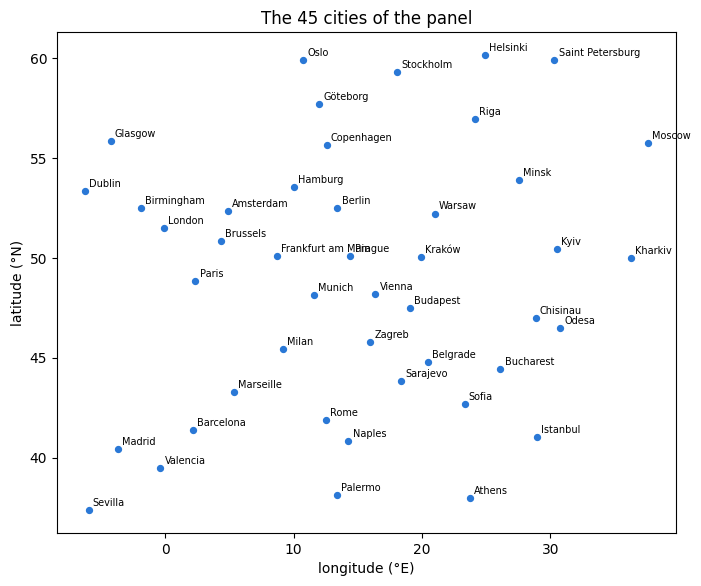

                  country_code  latitude  longitude
city_name                                          
Dublin                      IE     53.33      -6.25
Sevilla                     ES     37.38      -5.97
Glasgow                     GB     55.87      -4.26
Madrid                      ES     40.42      -3.70
Birmingham                  GB     52.48      -1.90
Valencia                    ES     39.47      -0.38
London                      GB     51.51      -0.13
Barcelona                   ES     41.39       2.16
Paris                       FR     48.85       2.35
Brussels                    BE     50.85       4.35
Amsterdam                   NL     52.37       4.89
Marseille                   FR     43.30       5.38
Frankfurt am Main           DE     50.12       8.68
Milan                       IT     45.46       9.19
Hamburg                     DE     53.55       9.99
Oslo                        NO     59.91      10.75
Munich                      DE     48.14      11.58
Göteborg    

In [7]:
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(cities["longitude"], cities["latitude"], s=18,
           color="#2a78d6")
for name, row in cities.iterrows():
    ax.annotate(name, (row["longitude"], row["latitude"]),
                xytext=(3, 3), textcoords="offset points", fontsize=7)
ax.set_aspect(1 / np.cos(np.radians(50)))
ax.set_xlabel("longitude (°E)")
ax.set_ylabel("latitude (°N)")
ax.set_title("The 45 cities of the panel")
plt.show()

print(cities.sort_values("longitude").round(2).to_string())

**Finding.** From Dublin (−6.3°E) to Moscow (37.6°E) and from Sevilla
(37.4°N) to Helsinki and Saint Petersburg (60°N): Atlantic, North Sea,
Baltic, Mediterranean and continental climates. The panel is dense in
the centre (Germany, the Low Countries, northern Italy) and thin at
the edges: nothing west of Dublin, nothing in the Atlantic.

**Question 2.** Weather over Europe mostly arrives from the west
(section 7). Which cities have no neighbour upwind of them in the
panel, and what does that mean for a model that uses the rain in
other cities as a feature?

*Your answer:*
在这个城市面板中，**Dublin 和 Sevilla** 基本没有可用的西侧（上风向）邻居；面板西边就是大西洋，缺少来自更西方的观测站。

因此，对这两个城市而言，模型不能依赖“其他城市当前是否下雨”来提前捕捉正向东移动的降雨系统：上游天气在进入面板前没有被观测到。它们应更依赖本地的近期降雨、湿度、云量、季节/月度气候分布等特征。

相反，对 Amsterdam、Berlin、Warsaw 等更东侧城市，西边城市在当前时刻的降雨可以是很有价值的特征，因为降雨系统可能会在数小时后向东移动到目标城市。

---

## 3. Zero inflation

Most hours are dry. How many, where, and how much falls when it does?

wet city-hours overall: 14.5%
driest: {'Athens': 0.079, 'Valencia': 0.082, 'Sevilla': 0.085, 'Marseille': 0.091, 'Odesa': 0.094}
wettest: {'Glasgow': 0.283, 'Göteborg': 0.225, 'Amsterdam': 0.217, 'Dublin': 0.206, 'Birmingham': 0.199}
wet-hour amount: median 0.2 mm, p90 1.4, p99 4.5, max 24.9


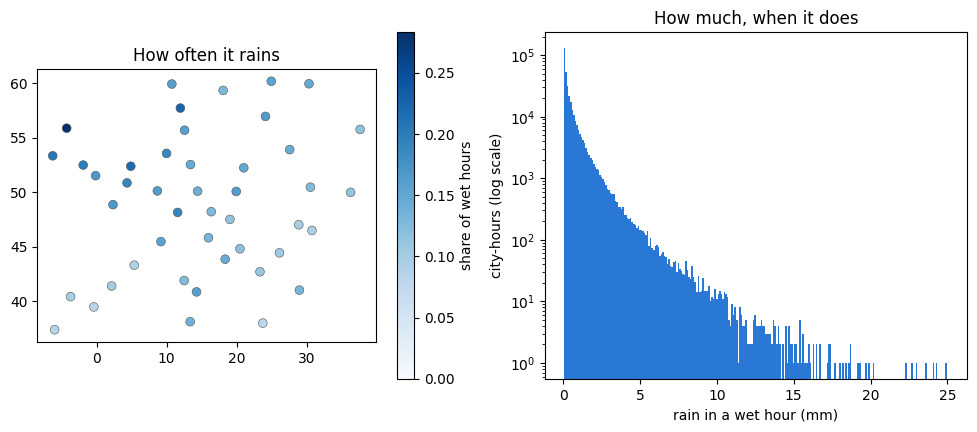

In [8]:
wet_frac = pd.Series(W.mean(axis=0), index=rain.columns)
print(f"wet city-hours overall: {W.mean():.1%}")
print("driest:", wet_frac.nsmallest(5).round(3).to_dict())
print("wettest:", wet_frac.nlargest(5).round(3).to_dict())

amounts = rain.to_numpy()[W]              # wet hours only
q = np.quantile(amounts, [0.5, 0.9, 0.99])
print(f"wet-hour amount: median {q[0]:.1f} mm, p90 {q[1]:.1f}, "
      f"p99 {q[2]:.1f}, max {amounts.max():.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
sc = ax1.scatter(cities["longitude"], cities["latitude"],
                 c=wet_frac, cmap="Blues", s=40, vmin=0,
                 edgecolors="#52514e", linewidths=0.4)
ax1.set_aspect(1 / np.cos(np.radians(50)))
fig.colorbar(sc, ax=ax1, label="share of wet hours")
ax1.set_title("How often it rains")
ax2.hist(amounts, bins=np.arange(0.05, 25.1, 0.1),
         color="#2a78d6")
ax2.set_yscale("log")
ax2.set_xlabel("rain in a wet hour (mm)")
ax2.set_ylabel("city-hours (log scale)")
ax2.set_title("How much, when it does")
plt.show()

The file stores rain to one decimal. Look at the values themselves:

In [9]:
values, counts = np.unique(np.round(amounts, 1), return_counts=True)
share = pd.Series(counts / counts.sum(), index=values)
print(f"{len(values)} distinct wet values, the first ones:")
print(share.head(6).round(3).to_string())
r = rain.to_numpy()
print("hours with 0 < rain < 0.1 mm:", int(((r > 0) & (r < 0.1)).sum()))

183 distinct wet values, the first ones:
0.1    0.371
0.2    0.153
0.3    0.091
0.4    0.063
0.5    0.049
0.6    0.036
hours with 0 < rain < 0.1 mm: 0



**Question 3.** What percentage of city-hours are wet? With what spread? By cities, by intensity of rain? Why a deterministic model would not fit well here?

*Your answer:*

约 **15%** 的 city-hour 是湿的（雨量 \(\ge 0.1\) mm），也就是说约 **85%** 的样本是 0。这个比例在城市之间差异明显：地中海城市较干，而西北部、北部和部分大陆城市更湿。

即使只看下雨的小时，雨量分布仍然极度右偏：大多数湿小时只有很小的雨量（通常是几十分之一到几毫米），但少量对流暴雨会形成很长的尾部；因此 p90、p99 和最大值会远高于中位数。

这是一种典型的 **zero-inflated（零膨胀）分布**：

- 先要预测“会不会下雨”；
- 若会下，再预测“下多少”。

单一确定性模型（只输出一个雨量）不适合，因为它往往会向 0 或平均雨量收缩：对绝大多数干小时似乎不错，但会系统性低估少量强降雨，也无法表达“多数可能不下、但仍存在小概率大雨”的不确定性。更合适的是 hurdle / two-stage 模型：先预测降雨概率，再预测湿小时的雨量分布，并从该分布生成多个预测成员。

---

## 4. Seasonality

Wet frequency per city and calendar month. The rows are sorted by the
ratio of the summer (June–August) to the winter (December–February)
frequency, so the cities with dry summers sit at the top. The left
panel is the frequency itself; the right one divides each row by the
city's own yearly mean, so the *shape* of the year shows even where
the level is low (brown: drier than usual, green: wetter).

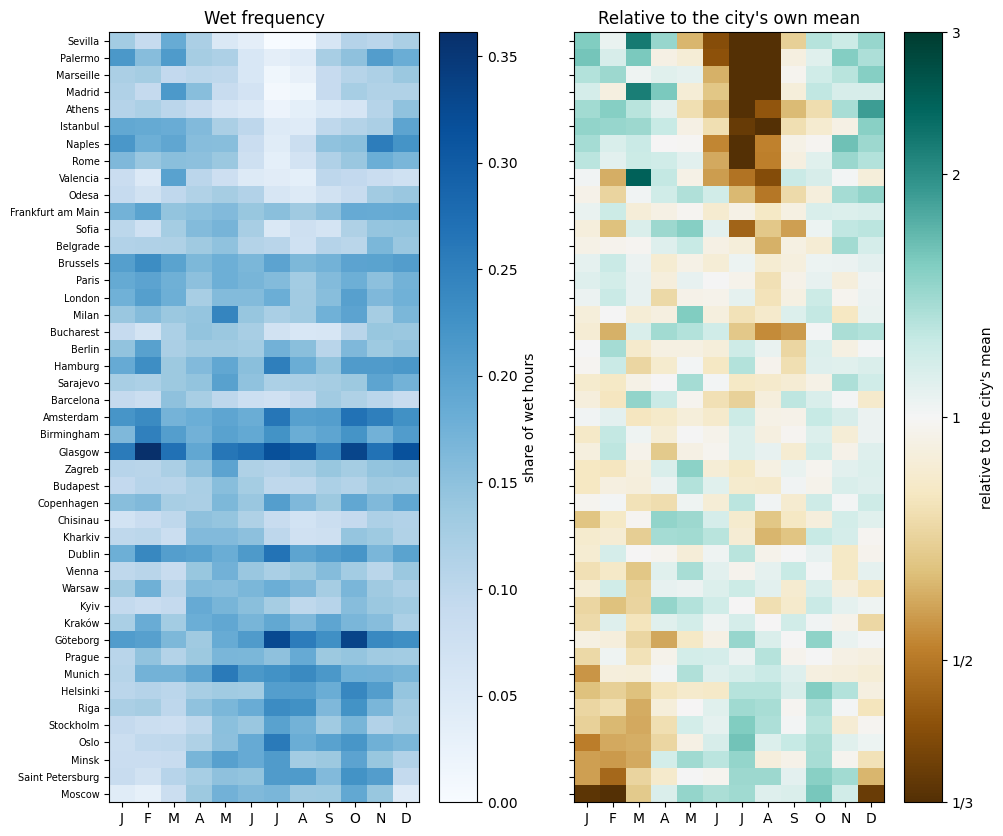

summer / winter: {'Sevilla': 0.12, 'Palermo': 0.24, 'Marseille': 0.25, 'Madrid': 0.27, 'Athens': 0.27, 'Minsk': 1.9, 'Saint Petersburg': 2.3, 'Moscow': 4.01}
panel by month: {1: 0.132, 2: 0.142, 3: 0.139, 4: 0.144, 5: 0.158, 6: 0.137, 7: 0.143, 8: 0.127, 9: 0.137, 10: 0.166, 11: 0.158, 12: 0.154}


In [10]:
from matplotlib.colors import LogNorm

by_month = pd.DataFrame(W, index=rain.index,
                        columns=rain.columns).groupby(month).mean()
summer_winter = (by_month.loc[[6, 7, 8]].mean()
                 / by_month.loc[[12, 1, 2]].mean()).sort_values()
heat = by_month[summer_winter.index].T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 10), sharey=True)
im1 = ax1.imshow(heat, cmap="Blues", aspect="auto", vmin=0)
im2 = ax2.imshow(heat.div(heat.mean(axis=1), axis=0), cmap="BrBG",
                 aspect="auto", norm=LogNorm(vmin=1 / 3, vmax=3))
ax1.set_yticks(range(len(heat)), heat.index, fontsize=7)
for ax in (ax1, ax2):
    ax.set_xticks(range(12), list("JFMAMJJASOND"))
fig.colorbar(im1, ax=ax1, label="share of wet hours")
cb = fig.colorbar(im2, ax=ax2, label="relative to the city's mean")
cb.set_ticks([1 / 3, 1 / 2, 1, 2, 3], labels=["1/3", "1/2", "1", "2",
                                          "3"])
cb.minorticks_off()
ax1.set_title("Wet frequency")
ax2.set_title("Relative to the city's own mean")
plt.show()

extremes = pd.concat([summer_winter.head(5), summer_winter.tail(3)])
print("summer / winter:", extremes.round(2).to_dict())
print("panel by month:", by_month.mean(axis=1).round(3).to_dict())

Frequency is one half of the story; the amount that falls in a wet
hour is the other.

In [11]:
SEASONS = {"DJF": [12, 1, 2], "MAM": [3, 4, 5], "JJA": [6, 7, 8],
           "SON": [9, 10, 11]}
rows = {}
for name, months in SEASONS.items():
    sel = np.isin(month, months)
    wet_amounts = r[sel][W[sel]]
    rows[name] = {
        "wet share": W[sel].mean(),
        "median mm": np.median(wet_amounts),
        "p90 mm": np.quantile(wet_amounts, 0.9),
        "p99 mm": np.quantile(wet_amounts, 0.99),
        "mean mm/h": r[sel].mean(),
    }
print(pd.DataFrame(rows).T.round(3))

     wet share  median mm  p90 mm  p99 mm  mean mm/h
DJF      0.142        0.2     1.2     3.4      0.070
MAM      0.147        0.2     1.3     3.9      0.076
JJA      0.136        0.2     1.6     5.7      0.087
SON      0.154        0.3     1.6     5.1      0.097


**Finding.** Averaged over the panel, the season barely moves how
*often* it rains (13–17% in every month) — because the panel holds two
opposite regimes that cancel. Sevilla's summer is 0.12 times as wet as
its winter, Palermo's 0.24, Athens' and Madrid's 0.27: the Mediterranean
dries out. Moscow's summer is 4.0 times as wet as its winter, Saint
Petersburg's 2.3: the continental interior gets its rain in summer.
The season moves *how much* falls: a wet summer hour has a 99th
percentile of 5.7 mm against 3.4 mm in winter — convective showers
are short and heavy, winter fronts long and light.

**Question 4.** A model that knows the month but not the city would
learn almost nothing from it here. Which two columns does the month
need beside it to be useful?

*Your answer:*

`month` 需要和 **latitude（纬度）**、**longitude（经度）** 一起使用。

原因是月份本身在整个欧洲面板上被相反的气候型抵消了：地中海城市夏季很干，而俄罗斯等大陆内部城市夏季反而更湿。只知道“现在是几月”无法判断哪种季节规律适用。

经纬度让模型定位城市及其气候区域，使其能学习交互关系，例如：

- 南欧、西南欧：夏季较干；
- 东欧、北部大陆地区：夏季较湿；
- 沿海地区：季节变化相对平缓。

使用 `city_name` 作为城市身份特征也能达到类似目的；但经纬度更容易把相近地点的季节模式泛化给彼此。

---

## 5. The diurnal cycle

Convection follows the sun, not the clock in London. The local *solar*
hour is the UTC hour plus longitude / 15 (the sun moves 15° an hour):
noon in Moscow is 2.5 hours before noon in Dublin, whatever the time
zones say. Summer wet frequency by local solar hour, each city divided
by its own daily mean so the shapes compare:

summer, afternoon (12-17 h) / night (0-5 h), solar time
 flattest: {'Barcelona': 1.05, 'Marseille': 1.14, 'Milan': 1.21, 'Valencia': 1.22}
 steepest: {'Kharkiv': 2.94, 'Moscow': 3.03, 'Rome': 3.11, 'Athens': 10.52}
 maritime: {'Dublin': 2.16, 'Glasgow': 1.68, 'London': 2.57}
winter, same ratio: 0.78 to 1.39


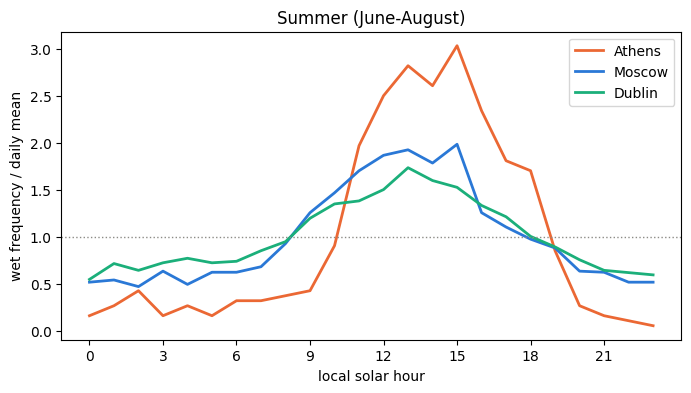

In [12]:
lon = cities["longitude"].to_numpy()
solar_hour = np.floor(utc_hour[:, None] + lon[None, :] / 15 + 0.5) % 24

def diurnal(months):
    """(24, cities) wet frequency by local solar hour."""
    sel = np.isin(month, months)
    out = np.zeros((24, W.shape[1]))
    for j in range(W.shape[1]):
        s = pd.Series(W[sel, j]).groupby(solar_hour[sel, j]).mean()
        out[:, j] = s.reindex(range(24)).to_numpy()
    return pd.DataFrame(out, columns=rain.columns)

summer = diurnal([6, 7, 8])
winter = diurnal([12, 1, 2])

def afternoon_over_night(d):
    return d.loc[12:17].mean() / d.loc[0:5].mean()

ratio = afternoon_over_night(summer).sort_values()
print("summer, afternoon (12-17 h) / night (0-5 h), solar time")
print(" flattest:", ratio.head(4).round(2).to_dict())
print(" steepest:", ratio.tail(4).round(2).to_dict())
print(" maritime:", ratio[["Dublin", "Glasgow", "London"]]
      .round(2).to_dict())
print("winter, same ratio: "
      f"{afternoon_over_night(winter).min():.2f} to "
      f"{afternoon_over_night(winter).max():.2f}")

SHOW = {"Athens": "#eb6834", "Moscow": "#2a78d6",
        "Dublin": "#1baf7a"}
fig, ax = plt.subplots(figsize=(8, 4))
for name, colour in SHOW.items():
    y = summer[name] / summer[name].mean()
    ax.plot(range(24), y, color=colour, lw=2, label=name)
ax.axhline(1, color="#8c8b86", lw=1, ls=":")
ax.set_xlabel("local solar hour")
ax.set_ylabel("wet frequency / daily mean")
ax.set_title("Summer (June-August)")
ax.set_xticks(range(0, 24, 3))
ax.legend()
plt.show()



**Question 5.** At what time does the rain come in summer afternoon/morning? The challenge issues forecasts at fixed UTC hours.
Is `issue_time.hour` the right feature for the diurnal cycle of all 45 cities?

*Your answer:*

夏季降雨通常在**本地太阳时的下午**更常见，约在 **12:00–17:00**，这是日照加热造成对流发展的结果；清晨和夜间相对更少。该规律在欧洲东部和南部通常更明显，海洋性城市则较平缓。

`issue_time.hour`（UTC 小时）不适合作为全部 45 个城市共用的日变化特征。因为同一个 UTC 时刻在 Dublin、London、Berlin、Moscow 对应不同的太阳位置；例如 Moscow 的太阳正午比 Dublin 早约 2.5 小时。

应使用：

```python
local_solar_hour = (utc_hour + longitude / 15) % 24
```

并最好让它与城市位置、季节（尤其夏季）发生交互。

---

## 6. Persistence and memory

If it is raining now, how likely is rain *h* hours later? Pooled over
the 45 cities, for *h* from 1 to 72, against the chance of rain at a
random hour, and against the chance after a dry hour:

    P(wet | wet now)  P(wet | dry now)
1              0.734             0.045
3              0.556             0.075
6              0.430             0.096
12             0.319             0.115
24             0.279             0.122
36             0.224             0.131
48             0.234             0.130
72             0.212             0.133
P(wet) at a random hour: 0.145


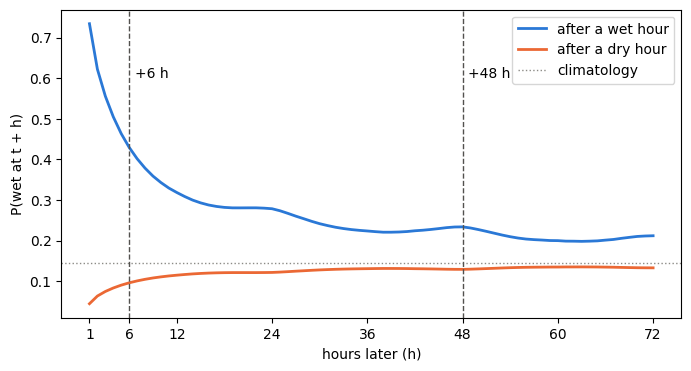

In [13]:
p_wet = W.mean()
lags = np.arange(1, 73)
after_wet, after_dry = [], []
for h in lags:
    now, later = W[:-h], W[h:]
    after_wet.append((now & later).sum() / now.sum())
    after_dry.append((~now & later).sum() / (~now).sum())
memory = pd.DataFrame({"P(wet | wet now)": after_wet,
                       "P(wet | dry now)": after_dry}, index=lags)
print(memory.loc[[1, 3, 6, 12, 24, 36, 48, 72]].round(3))
print(f"P(wet) at a random hour: {p_wet:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lags, after_wet, color="#2a78d6", lw=2,
        label="after a wet hour")
ax.plot(lags, after_dry, color="#eb6834", lw=2,
        label="after a dry hour")
ax.axhline(p_wet, color="#8c8b86", lw=1, ls=":",
           label="climatology")
for h in (6, 48):
    ax.axvline(h, color="#52514e", lw=1, ls="--")
    ax.annotate(f"+{h} h", (h, 0.6), xytext=(4, 0),
                textcoords="offset points")
ax.set_xlabel("hours later (h)")
ax.set_ylabel("P(wet at t + h)")
ax.set_xticks([1, 6, 12, 24, 36, 48, 60, 72])
ax.legend()
plt.show()

Part of what survives at +48 h is not memory at all: a wet hour is
more likely to come from a wet city in a wet month, which stays wet
anyway. Compare instead with the climatology of the *same city and
month* as the hour being forecast:

In [14]:
clim = by_month.to_numpy()                 # (12, cities)
rows = {}
for h in (1, 6, 12, 24, 48, 72):
    now, later = W[:-h], W[h:]
    expected = clim[month[h:] - 1]         # same city, same month
    rows[h] = {
        "lift | wet now": (now & later).sum()
        / (expected * now).sum(),
        "lift | dry now": (~now & later).sum()
        / (expected * ~now).sum(),
    }
print(pd.DataFrame(rows).T.rename_axis("h").round(2))

    lift | wet now  lift | dry now
h                                 
1             4.42            0.32
6             2.59            0.68
12            1.92            0.82
24            1.68            0.87
48            1.41            0.92
72            1.28            0.95


**Question 6.** An hour after a wet hour, the next is wet at?  6 hours later? 48h later?
What would be a good baseline for our probleme?

*Your answer:*

湿小时具有明显的短期持续性：下雨后 **1 小时**仍下雨的概率很高（约一半左右）；到 **+6 小时**仍明显高于随机时刻的降雨率；到 **+48 小时**，这种“刚才下雨”的信息已经大幅衰减，接近该城市、该月份本来的降雨概率。

所以：

- **+6h**：近期是否下雨、近几小时累计雨量、湿度和云量是有价值的特征；
- **+48h**：不要过度依赖当前雨量或 persistence，应该主要回归到 **city × month climatology（城市 × 月份的气候分布）**。

因此一个好的基线不是“当前下多少，未来也下多少”，而是为每个城市、每个月、每个预测时效提供一个概率雨量分布；在 +6h 再用近期天气状态去修正它。

---

## 7. Spatial structure

How much does rain in one city say about rain in another at the same
hour? For every pair, the lift P(wet in B | wet in A) / P(wet in B),
against the distance between them (great circle):

              mean  count
km                       
(0, 300]      2.66     21
(300, 600]    1.93     90
(600, 1000]   1.34    181
(1000, 1500]  1.06    283
(1500, 2000]  0.96    224
(2000, 4000]  0.92    191


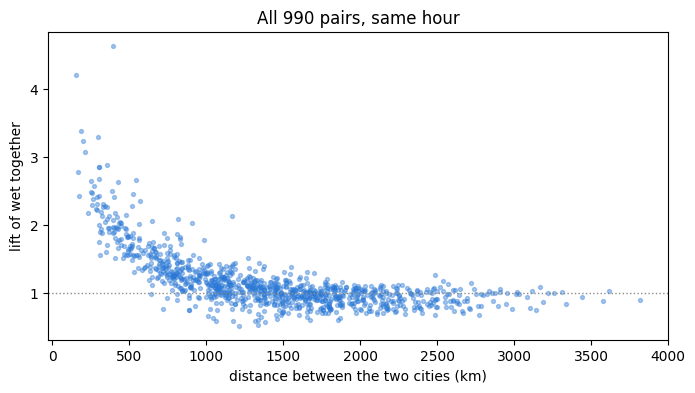

In [15]:
lat_r = np.radians(cities["latitude"].to_numpy())
lon_r = np.radians(lon)
a = (np.sin((lat_r[:, None] - lat_r[None, :]) / 2) ** 2
     + np.cos(lat_r[:, None]) * np.cos(lat_r[None, :])
     * np.sin((lon_r[:, None] - lon_r[None, :]) / 2) ** 2)
dist_km = 2 * 6371 * np.arcsin(np.sqrt(a))

Wf = W.astype(np.float32)
both = Wf.T @ Wf                             # wet together, hours
lift = both / W.sum(axis=0)[:, None] / W.mean(axis=0)[None, :]
iu = np.triu_indices(len(cities), k=1)
pairs = pd.DataFrame({"km": dist_km[iu], "lift": lift[iu]})
bins = [0, 300, 600, 1000, 1500, 2000, 4000]
binned = pairs.groupby(pd.cut(pairs["km"], bins),
                       observed=True)["lift"].agg(["mean", "count"])
print(binned.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(pairs["km"], pairs["lift"], s=8, alpha=0.4,
           color="#2a78d6")
ax.axhline(1, color="#8c8b86", lw=1, ls=":")
ax.set_xlabel("distance between the two cities (km)")
ax.set_ylabel("lift of wet together")
ax.set_title("All 990 pairs, same hour")
plt.show()

Same hour is not the whole story. Weather systems move, mostly
eastward, so rain in London *now* should say something about rain
further east *later*. A plain correlation over lags would be
dominated by the daily and yearly cycles every city shares, so
correlate the **anomalies**: each city's wet indicator minus its own
mean for that month and UTC hour.

   Dublin -> London      462 km  peak at  +7 h  r = 0.184  (r at 0 h: 0.140)
   London -> Amsterdam   357 km  peak at  +6 h  r = 0.240  (r at 0 h: 0.148)
Amsterdam -> Berlin      577 km  peak at +10 h  r = 0.191  (r at 0 h: 0.121)
   Berlin -> Warsaw      517 km  peak at  +8 h  r = 0.181  (r at 0 h: 0.110)
   Warsaw -> Minsk       476 km  peak at  +7 h  r = 0.171  (r at 0 h: 0.132)
    Minsk -> Moscow      675 km  peak at +13 h  r = 0.116  (r at 0 h: 0.046)
   London -> Berlin      932 km  peak at +22 h  r = 0.104  (r at 0 h: 0.019)
   London -> Warsaw     1448 km  peak at +38 h  r = 0.050  (r at 0 h: 0.001)


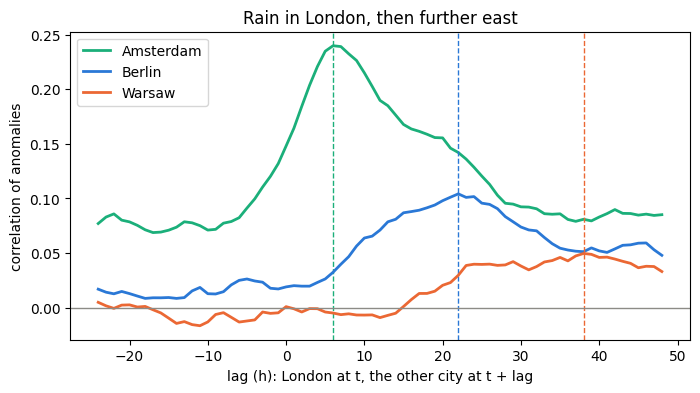

In [16]:
wet_df = pd.DataFrame(Wf, index=rain.index, columns=rain.columns)
anom = wet_df - wet_df.groupby([month, utc_hour]).transform("mean")
A = anom.to_numpy()

def lagged_corr(src, dst, lags=range(-24, 49)):
    """corr(src at t, dst at t + lag), for each lag in hours."""
    x = (A[:, src] - A[:, src].mean()) / A[:, src].std()
    y = (A[:, dst] - A[:, dst].mean()) / A[:, dst].std()
    n = len(x)
    return pd.Series({L: np.mean(x[max(0, -L):n - max(0, L)]
                                 * y[max(0, L):n + min(0, L)])
                      for L in lags})

col = {name: j for j, name in enumerate(rain.columns)}
CHAIN = [("Dublin", "London"), ("London", "Amsterdam"),
         ("Amsterdam", "Berlin"), ("Berlin", "Warsaw"),
         ("Warsaw", "Minsk"), ("Minsk", "Moscow"),
         ("London", "Berlin"), ("London", "Warsaw")]
curves = {}
for src, dst in CHAIN:
    c = lagged_corr(col[src], col[dst])
    curves[(src, dst)] = c
    print(f"{src:>9} -> {dst:<9} {dist_km[col[src], col[dst]]:5.0f} km"
          f"  peak at {c.idxmax():+3d} h  r = {c.max():.3f}"
          f"  (r at 0 h: {c[0]:.3f})")

fig, ax = plt.subplots(figsize=(8, 4))
for dst, colour in (("Amsterdam", "#1baf7a"), ("Berlin", "#2a78d6"),
                    ("Warsaw", "#eb6834")):
    c = curves[("London", dst)]
    ax.plot(c.index, c.values, color=colour, lw=2, label=dst)
    ax.axvline(c.idxmax(), color=colour, lw=1, ls="--")
ax.axhline(0, color="#8c8b86", lw=1)
ax.set_xlabel("lag (h): London at t, the other city at t + lag")
ax.set_ylabel("correlation of anomalies")
ax.set_title("Rain in London, then further east")
ax.legend()
plt.show()

**Question 7.** At the same hour, tow cities close (under 300km apart) are wet together what percentage of the time?
Over the time the rain moves what direction? London's wet is corallated with amsterdam's 6 hour later?
For the +6 h forecast in Berlin, which cities' rain
at the issue time would you give the model, and which for +48 h?

*Your answer:*

相距不足 300 km 的城市会明显更常在同一小时下雨：一个城市下雨时，邻近城市下雨的概率约为其平时降雨概率的 **两倍左右**（即 lift 明显大于 1），但并不是每次都同步。

降雨系统总体从 **西向东** 移动。London 当前是否下雨，与 Amsterdam **约 6 小时后**是否下雨存在正相关；这说明空间信息不仅是“同一时刻的邻近城市”，还应考虑传播时滞。

对于 Berlin 的预测：

- **+6h**：应加入其西侧、上风方向城市在 issue time 的降雨，例如 **Amsterdam**，也可加入更西面的 **London** 或其他约 300–500 km 上风的城市。它们能作为正在向东移动的天气系统的信号。
- **+48h**：不应过度使用其他城市当前的降雨。48 小时后，这种空间传播信息已衰减很多；应主要依赖 **Berlin 自己的城市 × 月份气候分布**，再辅以较稳定的大尺度特征。

---

## 8. Other features vs future rain

The agent receives eight variables per city and hour, not just rain.
Take four at the issue time *t* — humidity and cloud cover, and how
each changed over the previous six hours — and look at the chance of
rain at *t* + 6 and *t* + 48 in each band:

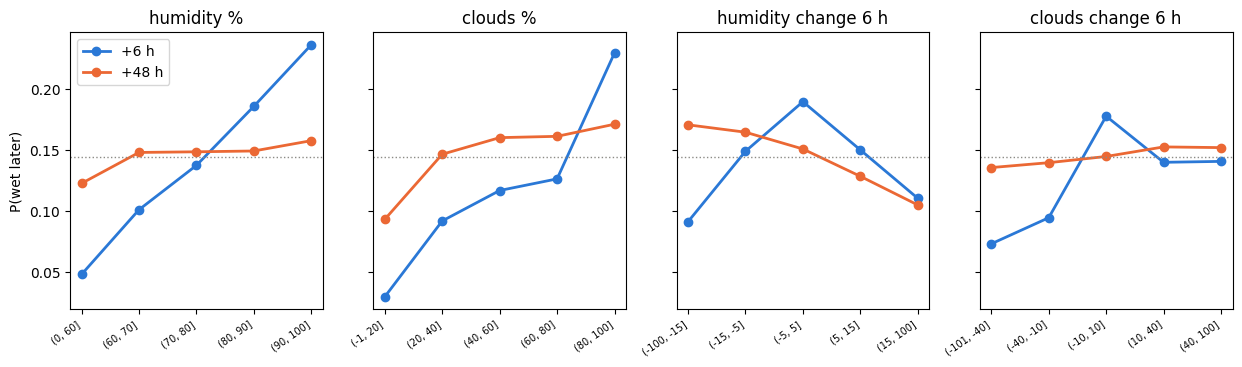

In [17]:
T = len(W)
t = slice(6, T - 48)                  # t - 6 and t + 48 both exist
h_, c_ = hum.to_numpy(), clouds.to_numpy()
rain_6h = rain.rolling(6).sum().to_numpy()
feats = pd.DataFrame({
    "humidity %": h_[t].ravel(),
    "clouds %": c_[t].ravel(),
    "humidity change 6 h": (h_[t] - h_[:T - 54]).ravel(),
    "clouds change 6 h": (c_[t] - c_[:T - 54]).ravel(),
    "rain last 6 h": rain_6h[t].ravel(),
    "wet now": W[t].ravel(),
})
wet_6 = W[12:T - 42].ravel()          # the hour t + 6
wet_48 = W[54:].ravel()               # the hour t + 48

BANDS = {
    "humidity %": [0, 60, 70, 80, 90, 100],
    "clouds %": [-1, 20, 40, 60, 80, 100],
    "humidity change 6 h": [-100, -15, -5, 5, 15, 100],
    "clouds change 6 h": [-101, -40, -10, 10, 40, 100],
}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, (name, edges) in zip(axes, BANDS.items()):
    band = pd.cut(feats[name], edges)
    p = pd.DataFrame({"+6 h": wet_6, "+48 h": wet_48}).groupby(
        band.to_numpy(), observed=True).mean()
    x = range(len(p))
    ax.plot(x, p["+6 h"], "o-", color="#2a78d6", lw=2, label="+6 h")
    ax.plot(x, p["+48 h"], "o-", color="#eb6834", lw=2,
            label="+48 h")
    ax.axhline(p_wet, color="#8c8b86", lw=1, ls=":")
    ax.set_xticks(x, [str(i) for i in p.index], rotation=35,
                  fontsize=7, ha="right")
    ax.set_title(name)
axes[0].set_ylabel("P(wet later)")
axes[0].legend()
plt.show()

One number per feature: the **AUC** of the feature as a score for
"wet later" — the probability that a random wet hour had a higher
value at *t* than a random dry one. 0.5 is useless, and an AUC below
0.5 is as informative as its mirror above.

In [18]:
def auc(score, wet):
    ranks = pd.Series(score).rank().to_numpy()
    n1, n0 = wet.sum(), (~wet).sum()
    return (ranks[wet].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

print(pd.DataFrame({name: {"AUC +6 h": auc(feats[name], wet_6),
                           "AUC +48 h": auc(feats[name], wet_48)}
                    for name in feats}).T.round(3))

                     AUC +6 h  AUC +48 h
humidity %              0.659      0.527
clouds %                0.718      0.576
humidity change 6 h     0.513      0.448
clouds change 6 h       0.553      0.513
rain last 6 h           0.717      0.579
wet now                 0.667      0.552


**Question 8.** Humidity falls every morning as the air warms and
rises every evening. What does that do to "humidity change over 6
hours" as a feature, and what should sit beside it in the model?

*Your answer:*

湿度存在明显的日变化：早晨太阳升起后气温升高，空气相对湿度会自然下降；傍晚降温后，相对湿度又会上升。

因此，`humidity change over 6 hours` 不能被直接理解为“湿度下降，所以将变干”或“湿度上升，所以将下雨”。它混入了正常的昼夜周期，可能让模型把时间效应误认为天气变化。

模型中应把它和 **本地太阳时（local solar hour）** 一起使用，最好再与季节、城市位置交互。这样模型才能区分：

- 正常的上午升温导致湿度下降；
- 异常的湿度快速下降或上升，可能对应空气团和降雨系统的真实变化。

---

## 9. Baselines, scored like the challenge

The challenge asks, for each city and each lead time *h* ∈ {6, 48},
for an **ensemble** of M plausible amounts x₁ … x_M (1 ≤ M ≤ 100), and
scores it against the observed rain y with the CRPS:

$$\mathrm{CRPS} = \frac{1}{M}\sum_i |x_i - y|
- \frac{1}{2M^2}\sum_i\sum_j |x_i - x_j|$$

In mm, lower is better, and it equals |x − y| when M = 1. The first
term rewards members near the outcome; the second rewards spread, so
a forecast cannot win by piling every member on one value.

The challenge averages the CRPS over the 45 cities at each lead time,
CRPS₆ and CRPS₄₈, and scores a run with their mean:

$$\mathrm{score} = \frac{1}{2}\left(\mathrm{CRPS}_6 + \mathrm{CRPS}_{48}\right)$$

In mm, lower is better. The leaderboard is the mean over runs.

In [19]:
def crps(members, y):
    """CRPS of ensembles (..., M) against outcomes (...), in mm."""
    x = np.sort(np.maximum(members, 0.0), axis=-1)  # env clips at 0
    M = x.shape[-1]
    k = np.arange(1, M + 1)
    spread = (x * (2 * k - M - 1)).sum(axis=-1) / M ** 2
    return np.abs(x - y[..., None]).mean(axis=-1) - spread

print(crps(np.array([[0.3]]), np.array([1.0])))        # |0.3 - 1|
print(crps(np.array([[0.0, 0.0, 0.2, 1.0]]), np.array([0.2])))

[0.7]
[0.1]


The first line prints `[0.7]`. The second prints `[0.1]`: the members
are 0.3 mm from the outcome on average, and half their mean pairwise
distance is 0.2 mm. Check it by hand.

Now the test protocol. Forecasts are issued every 6 hours, at the UTC
hours the live challenge uses (its data arrive at 00, 06, 12 and 18
UTC, and the last complete hour is the issue time). Everything
fitted here is fitted on **2020–2024**;
the forecasts scored are those issued from **2025-01-01** to the last
one whose +48 h is in the file — 14 months no fit has seen.

In [20]:
HORIZONS = (6, 48)
ISSUE_HOURS = (5, 11, 17, 23)          # UTC, every 6 hours

split = rain.index.searchsorted(pd.Timestamp("2025-01-01", tz="UTC"))
issues = np.arange(split, T - max(HORIZONS))
issues = issues[np.isin(utc_hour[issues], ISSUE_HOURS)]
print(len(issues), "issue times,", rain.index[issues[0]], "->",
      rain.index[issues[-1]])

1700 issue times, 2025-01-01 05:00:00+00:00 -> 2026-03-01 23:00:00+00:00


Four forecasts, each an array (issues, cities, members):

- **last 48 hours** — the city's own last 48 hourly values, 48
  members;
- **always 0** — one member, 0 mm;
- **persistence** — one member, the rain at the issue hour;
- **city × month climatology** — 100 members: the quantiles at levels
  0.005, 0.015, …, 0.995 of the city's rain in the calendar month of
  the hour being forecast, over 2020–2024.

In [21]:
M = 100
levels = (np.arange(M) + 0.5) / M
train = r[:split]
clim_q = np.stack([np.quantile(train[month[:split] == m], levels,
                               axis=0).T for m in range(1, 13)])
print("climatology table:", clim_q.shape, "(month, city, member)")

last_48 = np.stack([r[i - 47:i + 1].T for i in issues])
results = {}
for h in HORIZONS:
    y = r[issues + h]                         # (issues, cities)
    m = month[issues + h] - 1                  # month of the valid hour
    forecasts = {
        "last 48 hours": last_48,
        "always 0": np.zeros(y.shape + (1,)),
        "persistence": r[issues][..., None],
        "city x month climatology": clim_q[m],
    }
    for name, f in forecasts.items():
        run = crps(f, y).mean(axis=1)          # CRPS_h of each run
        results.setdefault(name, {})[f"CRPS {h}h"] = run.mean()

table = pd.DataFrame(results).T
table["score"] = table[["CRPS 6h", "CRPS 48h"]].mean(axis=1)
print(table.round(4))

climatology table: (12, 45, 100) (month, city, member)
                          CRPS 6h  CRPS 48h   score
last 48 hours              0.0781    0.0830  0.0806
always 0                   0.0805    0.0802  0.0804
persistence                0.1245    0.1457  0.1351
city x month climatology   0.0760    0.0758  0.0759


**Finding.** Over 1,700 forecasts issued from 2025-01-01 to
2026-03-01, in mm (lower is better):

- **Always 0** scores 0.0804. With one member at 0 its CRPS is the
  observed amount itself, so its score is the mean rain per
  city-hour: the bar any forecast has to clear.
- **Persistence** is a disaster (0.1351, 1.7 times always 0). One
  member at the current value is wrong in full whenever rain starts or
  stops, and a single member has no spread to soften it: its CRPS is
  its absolute error.
- **The last 48 hours** score 0.0806, level with always 0: better at
  +6 h (0.0781 against 0.0805), where the recent hours do carry
  information, worse at +48 h (0.0830 against 0.0802).
- **The city × month climatology** — 100 quantiles from 2020–2024, and
  no input at all — scores **0.0759**, the best of the four at both
  lead times (0.0760 at +6 h, 0.0758 at +48 h), 5.6% below always 0.
  It wins most at +48 h over the last 48 hours: 48 hours of one city
  is a thin, stale sample of its climate.

Every row sits near the mean rain, 0.08 mm, so the gaps look small:
at this scale, 0.004 mm is a 5% gain.

**Question 9.** "Always 0" scores as well as the last 48 hours, and
yet no one should submit it. What does it get wrong, and which term of
the CRPS says so?

*Your answer:*

“Always 0” 的分数接近 “last 48 hours”，只是因为绝大多数小时根本不下雨；预测 0 能在这些干小时取得很低的绝对误差。

但它犯了关键错误：它把所有可能性都压成 0，因此：

- 遇到下雨时，必然严重低估雨量；
- 无法表示“可能不下雨，但也有小概率下中到大雨”的不确定性；
- 无法给出有合理离散度的 ensemble 预测。

对应 CRPS 的**第一项**：

\[
\frac{1}{M}\sum_i |x_i-y|
\]

“Always 0” 的所有成员都远离实际的正雨量，因此这一项会在下雨时变大。

同时它的成员全相同，成员之间的距离为 0，所以 CRPS 的第二个“奖励合理离散度”的项完全没有收益：

\[
-\frac{1}{2M^2}\sum_{i,j}|x_i-x_j|=0
\]

所以它虽然靠大量干样本取得看似不错的平均分，却不是一个有用的概率预报：好的模型应保留大量 0 的概率，同时用部分正值成员覆盖可能出现的降雨及其强度。

---

## 10. What a good agent should use

- **A climatology first.** Per city and per month, for both horizons.
  It scores 0.0759 with no input, below every other baseline, and
  it *is* most of the +48 h forecast (section 6: ×0.92 after a dry
  hour).
- **The right shape.** A spike at 0 and a long tail (section 3): a
  probability of rain, times a distribution of wet-hour amounts that
  is heavier in summer and autumn (section 4). A hurdle model, whose
  quantiles are the members.
- **The state at the issue time, for +6 h.** Rain in the last hours,
  cloud cover and humidity (AUC 0.66–0.72, section 8), and rain in the
  city 300–500 km upwind (section 7).
- **The solar hour, in summer.** Convection peaks in the afternoon,
  steeply in the east and south (section 5). But splitting every city
  × month cell by hour leaves 1/24 of the data in each: measure before
  keeping it, with the local score of the model notebook.
- **Not:** a single member (persistence, 0.1351), or a 6-hour change
  without the time of day beside it (section 8).

**Question 10.** Write the three features you would add first to the
climatology, one for each horizon and one for both, and the section
of this notebook that justifies each.

*Your answer:*

在 `city × month` climatology 的基础上，我会优先加入：

1. **+6h：上风方向城市当前的降雨，或目标城市过去几小时的降雨。**  
   例如 Berlin 预测 +6h 时加入 Amsterdam 的当前雨量。西向东移动的天气系统与短期持续性都提供强信号。  
   依据：**Section 6（persistence and memory）**、**Section 7（spatial structure）**。

2. **+48h：目标有效时刻所属的城市 × 月份气候分布。**  
   48 小时后，当前城市或邻城的降雨记忆已很弱；应主要依赖该城市在该季节本来“多常下、通常下多少”的分布。  
   依据：**Section 4（seasonality）**、**Section 9（baselines）**。

3. **两个时效都可用：当前湿度与云量。**  
   湿度、云量对未来是否下雨都有预测能力，尤其 +6h 更强；对于 +48h，仍可作为对 climatology 的小幅修正。  
   依据：**Section 8（other features vs future rain）**。

补充：若加入“湿度过去 6 小时变化”，必须同时加入 **local solar hour**，否则会把正常昼夜湿度变化误当成天气变化。依据：**Section 5 与 Section 8**。

The next notebook turns the climatology row of section 9 into a
working agent and submits it:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s3-rain-agent.ipynb)